## Step 1: Installation and Setup

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Data preprocessing

In [4]:
# Importing the dataset
from tensorflow.keras.datasets import mnist

In [5]:
# Loading the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


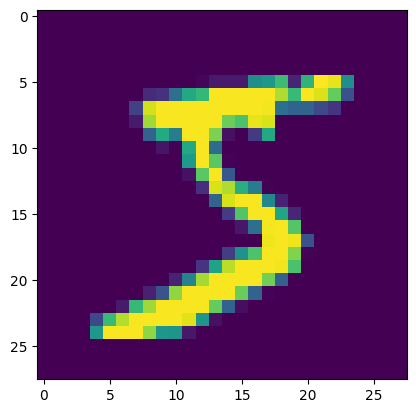

In [6]:
plt.imshow(x_train[0])

In [7]:
y_train[0]

np.uint8(5)

In [8]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [9]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

In [10]:
x_train.min(), x_train.max()

(np.uint8(0), np.uint8(255))

In [11]:
y_train.min(), y_train.max()

(np.uint8(0), np.uint8(9))

In [12]:
# Normalize the images
x_train = x_train/255.0
x_test = x_test/255.0

In [13]:
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0))

In [16]:
# Reshape the images
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

In [17]:
x_test.shape, x_test.shape

((10000, 28, 28, 1), (10000, 28, 28, 1))

In [18]:
input_shape = x_train[0].shape

In [19]:
print(input_shape)

(28, 28, 1)


## Step 3: Building the Model

In [20]:
# Define an object
model = tf.keras.models.Sequential()

In [22]:
# Adding the first CNN layer
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))

# Adding the second CNN layer
model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'))

# Adding maxpool layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

# Adding dropout layer
model.add(tf.keras.layers.Dropout(0.4))

# Adding flatten layer
model.add(tf.keras.layers.Flatten())

# Adding fully connected (dense layer)
model.add(tf.keras.layers.Dense(units=128, activation='relu'))

# Output layer
model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

## Step 4: Training the model

In [25]:
history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.1706 - sparse_categorical_accuracy: 0.9495 - val_loss: 0.0589 - val_sparse_categorical_accuracy: 0.9816
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0512 - sparse_categorical_accuracy: 0.9845 - val_loss: 0.0324 - val_sparse_categorical_accuracy: 0.9902
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0349 - sparse_categorical_accuracy: 0.9886 - val_loss: 0.0328 - val_sparse_categorical_accuracy: 0.9893
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0258 - sparse_categorical_accuracy: 0.9915 - val_loss: 0.0303 - val_sparse_categorical_accuracy: 0.9895
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0201 - sparse_categorical_accuracy: 0.9934 - val_loss: 0.0298 - val_sparse_categorical_accuracy: 0.9898
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0154 - sparse_categorical_accuracy: 0.9946 - val_loss: 0.0324 - val_sparse_categorical_accuracy: 0.9896
E

In [26]:
# Model predictions
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [29]:
# Get the predicted digit class index

print(f"Predicted Class: {np.argmax(y_pred[15])}")
print(f"Actual Class:    {y_test[15]}")

Predicted Class: 5
Actual Class:    5


In [30]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))
print(cm)

[[ 969    0    1    1    0    3    2    0    4    0]
 [   0 1125    0    0    0    2    3    2    2    1]
 [   0    4 1019    1    0    0    1    7    0    0]
 [   0    0    1 1004    0    4    0    0    1    0]
 [   0    0    0    0  971    0    4    0    1    6]
 [   0    0    1    4    0  886    1    0    0    0]
 [   4    1    0    0    1    2  949    0    1    0]
 [   0    0    4    0    0    0    0 1022    1    1]
 [   1    1    1    0    0    0    1    0  968    2]
 [   0    1    0    1    6    5    0    0    4  992]]


In [31]:
acc_cm = accuracy_score(y_test, np.argmax(y_pred, axis=1))
print(acc_cm)

0.9905


## Step 5: Learning Curve

In [32]:
def learning_curve(history, epochs):

  # Training vs Validation accuracy
  epoch_range = range(1, epochs+1)
  plt.plot(epoch_range, history.history['sparse_categorical_accuracy'])
  plt.plot(epoch_range, history.history['val_sparse_categorical_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

  # Training vs Validation loss
  plt.plot(epoch_range, history.history['loss'])
  plt.plot(epoch_range, history.history['val_loss'])
  plt.title('Model Loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

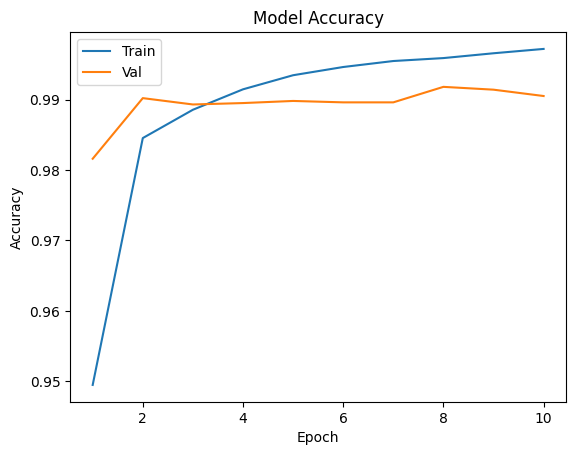

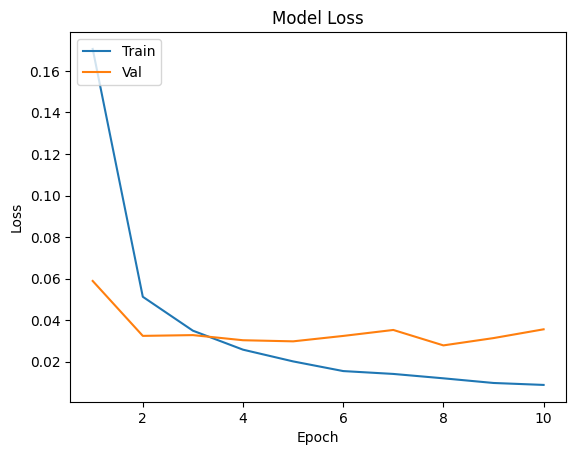

In [33]:
learning_curve(history, 10)